# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import joblib

## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [18]:
df = pd.read_csv('data/dayofweek.csv')

X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X, y, test_size=0.2, random_state=21
)

print("Распределение дней в ПЛОХОМ тесте (в штуках):")
print(y_test_bad.value_counts().sort_index())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

print("\nРаспределение дней в ХОРОШЕМ тесте (со stratify):")
print(y_test.value_counts().sort_index())

print("\nСравнение долей (в %) для ХОРОШЕГО разбиения:")
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
test_dist = y_test.value_counts(normalize=True).sort_index() * 100

dist_df = pd.DataFrame({'Train %': train_dist, 'Test %': test_dist})
print(dist_df.round(2))

Распределение дней в ПЛОХОМ тесте (в штуках):
dayofweek
0    31
1    52
2    24
3    83
4    24
5    55
6    69
Name: count, dtype: int64

Распределение дней в ХОРОШЕМ тесте (со stratify):
dayofweek
0    27
1    55
2    30
3    80
4    21
5    54
6    71
Name: count, dtype: int64

Сравнение долей (в %) для ХОРОШЕГО разбиения:
           Train %  Test %
dayofweek                 
0             8.09    7.99
1            16.25   16.27
2             8.83    8.88
3            23.44   23.67
4             6.16    6.21
5            16.10   15.98
6            21.14   21.01


## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [19]:
logreg = LogisticRegression(random_state=21, fit_intercept=False, multi_class='ovr')
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Logreg test accuracy: {acc_logreg:.5f}")

Logreg test accuracy: 0.61538


/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: Runtime

### b. SVM

In [20]:
svc = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)
print(f"SVM test accuracy: {acc_svc:.5f}")

SVM test accuracy: 0.63018


### c. Decision tree

In [21]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
dtc.fit(X_train, y_train)

y_pred_dtc = dtc.predict(X_test)
acc_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"Decision tree test accuracy: {acc_dtc:.5f}")

Decision tree test accuracy: 0.52959


### d. Random forest

In [22]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rfc.fit(X_train, y_train)

y_pred_rfc = rfc.predict(X_test)
acc_rfc = accuracy_score(y_test, y_pred_rfc)
print(f"Random forest test accuracy: {acc_rfc}")

Random forest test accuracy: 0.9289940828402367


Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous?

Больше всего отличается рандом форест - точность упала с 1 до 0.928

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [23]:
logreg_cv = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')

scores_logreg = cross_val_score(logreg_cv, X_train, y_train, cv=10, scoring='accuracy')

print(f"Logreg CV Mean Accuracy: {scores_logreg.mean():.5f}")
print(f"Logreg CV Standard Deviation: {scores_logreg.std():.5f}")

Logreg CV Mean Accuracy: 0.58160
Logreg CV Standard Deviation: 0.02532


/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:2

### b. SVM

In [24]:
svc_cv = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))

scores_svc = cross_val_score(svc_cv, X_train, y_train, cv=10, scoring='accuracy')

print(f"SVM CV Mean Accuracy: {scores_svc.mean():.5f}")
print(f"SVM CV Standard Deviation: {scores_svc.std():.5f}")

SVM CV Mean Accuracy: 0.56755
SVM CV Standard Deviation: 0.03660


### c. Decision tree

In [25]:
dtc_cv = DecisionTreeClassifier(max_depth=4, random_state=21)

scores_dtc = cross_val_score(dtc_cv, X_train, y_train, cv=10, scoring='accuracy')

print(f"Decision Tree CV Mean Accuracy: {scores_dtc.mean():.5f}")
print(f"Decision Tree CV Standard Deviation: {scores_dtc.std():.5f}")

Decision Tree CV Mean Accuracy: 0.50889
Decision Tree CV Standard Deviation: 0.03190


### d. Random forest

In [26]:
rfc_cv = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)

scores_rfc = cross_val_score(rfc_cv, X_train, y_train, cv=10, scoring='accuracy')

print(f"Random Forest CV Mean Accuracy: {scores_rfc.mean():.5f}")
print(f"Random Forest CV Standard Deviation: {scores_rfc.std():.5f}")

Random Forest CV Mean Accuracy: 0.91766
Random Forest CV Standard Deviation: 0.02160


## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [27]:
rfc_tune = RandomForestClassifier(random_state=21)

param_grid = {
    'n_estimators': [50, 100, 200],  
    'max_depth': [15, 25, None]     
}

print("Запускаем поиск лучших параметров (GridSearchCV)... Это займет немного времени.")

grid_search = GridSearchCV(rfc_tune, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Точность на кросс-валидации (CV): {grid_search.best_score_:.5f}")

best_model = grid_search.best_estimator_

Запускаем поиск лучших параметров (GridSearchCV)... Это займет немного времени.

Лучшие параметры: {'max_depth': 25, 'n_estimators': 200}
Точность на кросс-валидации (CV): 0.90281


Итоговая точность на тестовой выборке (TEST): 0.93195


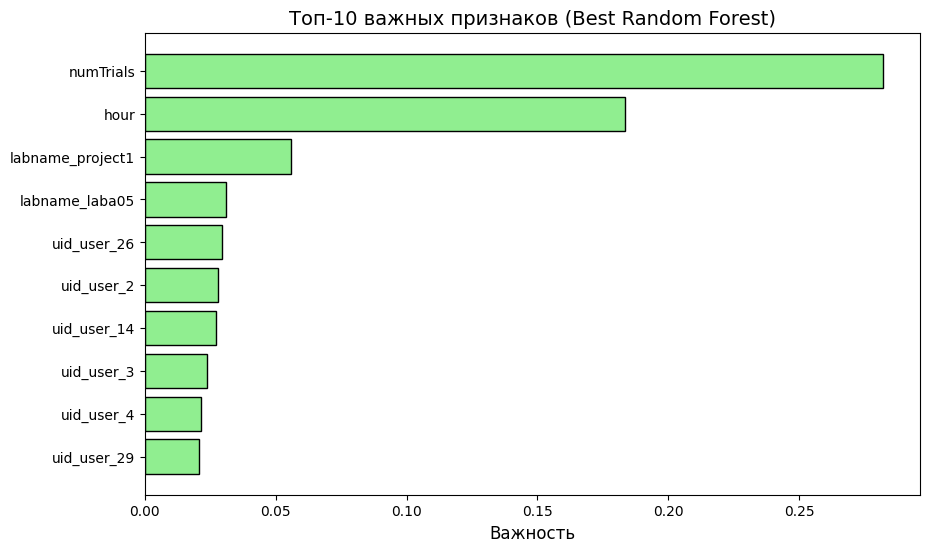

In [28]:
y_pred_final = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_final)

print(f"Итоговая точность на тестовой выборке (TEST): {final_accuracy:.5f}")

def plot_feature_importances(importances, feature_names, top_n=10, title="Feature Importances"):
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    top_features = imp_df.sort_values(by='importance', ascending=False).head(top_n)
    top_features = top_features.sort_values(by='importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_features['feature'], top_features['importance'], color='lightgreen', edgecolor='black')
    plt.title(title, fontsize=14)
    plt.xlabel('Важность', fontsize=12)
    plt.show()

plot_feature_importances(best_model.feature_importances_, X_train.columns, top_n=10, title="Топ-10 важных признаков (Best Random Forest)")

In [29]:
model_filename = 'data/random_forest_best.joblib'
joblib.dump(best_model, model_filename)
print(f"Модель успешно сохранена в {model_filename}")

loaded_model = joblib.load(model_filename)

loaded_pred = loaded_model.predict(X_test)
loaded_accuracy = accuracy_score(y_test, loaded_pred)

print(f"Точность загруженной модели: {loaded_accuracy:.5f}")

Модель успешно сохранена в data/random_forest_best.joblib
Точность загруженной модели: 0.93195
